<a href="https://colab.research.google.com/github/Himanshu-bansal-9256/Himanshu_Bansal_JECRC_FOUNDATION_Celebal_Tech_Week_Assessments/blob/main/Week2_%3CHimanshu_Bansal%3E.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Install & Import Librarie

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings('ignore')

**import data**

In [ ]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
print(df.head(10))

   Year  Month         Region       Model  Estimated_Deliveries  \
0  2023      5         Europe     Model S                 17646   
1  2015      2           Asia     Model X                  3797   
2  2019      1  North America     Model X                  8411   
3  2021      2  North America     Model 3                  6555   
4  2016     12    Middle East     Model Y                 12374   
5  2020      4           Asia     Model X                  4656   
6  2015     11           Asia     Model 3                  7717   
7  2020      6         Europe  Cybertruck                  8410   
8  2022      4         Europe     Model S                 15145   
9  2021      3    Middle East     Model Y                  7790   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                  

In [ ]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (2640, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


**Data Cleaning**

In [ ]:
print(df.isnull().sum()) # that's mean dataset have not and any null value

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [ ]:
print(df.duplicated().sum()) # this line checks whether the daatset have duplcates or not in our condition that have no dupliactes

0


**reason why we don't use fillna and dropna :**

> my dataset have not any type of missing values aur dupliacted values so be don't use dropna and fillna**

**EDA**

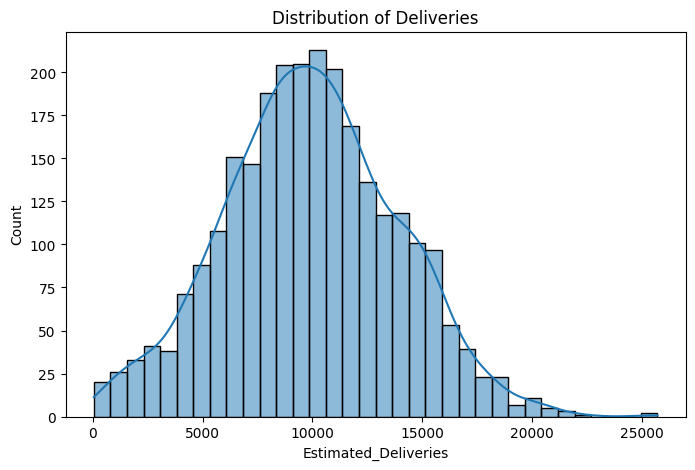

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Estimated_Deliveries'],
    kde=True
)

plt.title("Distribution of Deliveries")

plt.show()

**Why we used it**

We used histogram to understand how Tesla estimated deliveries are spread out, It helps us see how the data is distributed, where most observations are concentrated if the data is skewed and if there are any outliers. Understanding how the target variable is distributed is important before we build machine learning models.

**What we observed**

Most of the delivery values are around the range. This tells us that Tesla deliveries are pretty consistent. The distribution looks almost normal with some variation. This makes it suitable, for regression modeling.

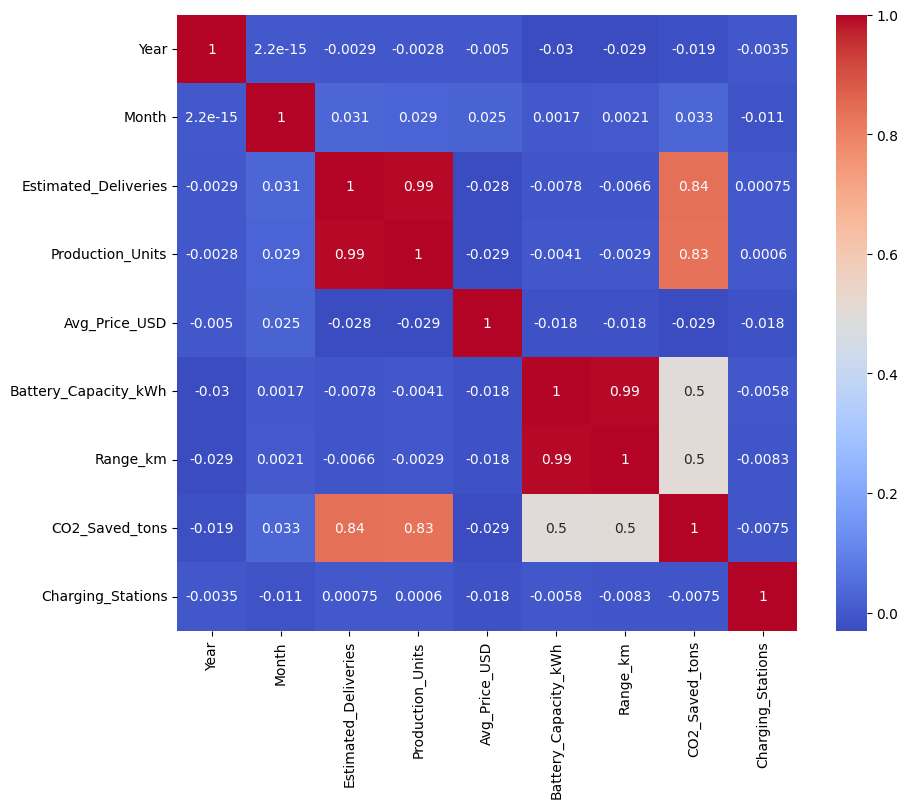

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

**Why we used it**

A correlation heatmap was used to examine relationships between numerical features. It helps identify which variables are strongly related to the target variable and detects multicollinearity among predictors.

**What we observed**

From this heatmap:

> Estimated_Deliveries ↔ Production_Units = 0.99,

> Estimated_Deliveries ↔ CO2_Saved_tons = 0.84,

> Battery_Capacity_kWh ↔ Range_km = 0.99

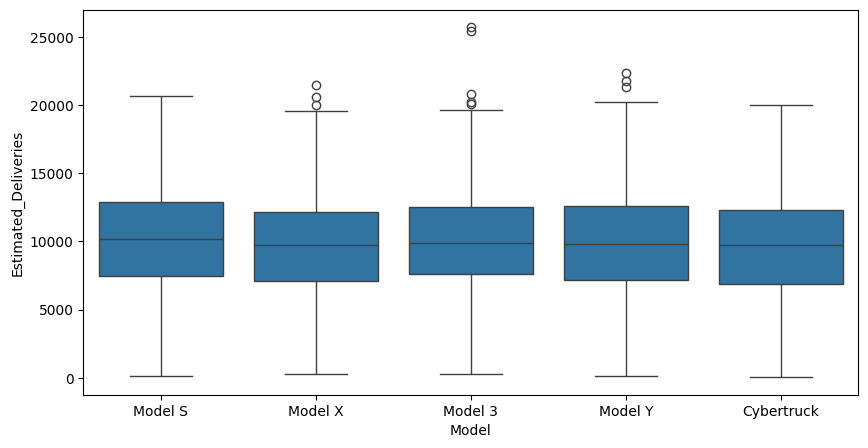

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='Model',
    y='Estimated_Deliveries',
    data=df
)

plt.show()

**Why we used it**

we used boxplot to compare the distribution of estimated deliveries across different Tesla vehicle models. It can helps us to visualize median values, variability, and potential outliers for each model.

**What we observed**

From this boxplot:

Model Y and Model 3 show some high delivery outliers.

Median deliveries are fairly similar across models.

Distribution spreads are comparable.

# Feature Engineering

In [ ]:
# Create a Time Index

df['Time_Index'] = (
    (df['Year'] - df['Year'].min())*12
    + df['Month']
)

**Why we used it**

A Time Index feature was created to represent the chronological progression of observations. This allows machine learning models to capture temporal patterns and trends over time.

**What it does**

The Time Index converts Year and Month information into a continuous numerical sequence, enabling the model to understand the order of events.

# Now Applying Encoding Techniques

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df['Region'] = le_region.fit_transform(df['Region'])

df['Model'] = le_model.fit_transform(df['Model'])

df['Source_Type'] = le_source.fit_transform(
    df['Source_Type']
)

**Why we use it**

Before encoding: my region are

> North America

> Europe

> Asia

Machine Learning model sees these type of data and can not understand anything

After encoding:

> North America → 0

> Europe → 1

> Asia → 2

now my ml model understand the regions that's why be can use labelencoding

# Lag features

In [ ]:
# sort first
df = df.sort_values(
    ['Year','Month']
)

# apply leag feature

df['Lag_1'] = df[
    'Estimated_Deliveries'
].shift(1)

**Why we used it:**

A lag feature was implemented to include data from past delivery periods. Past delivery values frequently shape future demand trends and enhance forecasting accuracy.

**What it does**

Lag_1 holds the delivery value from the prior time period, allowing the model to capture temporal dependencies.

# rolling mean

In [ ]:
df['Rolling_Mean_3'] = (
    df['Estimated_Deliveries']
    .rolling(3)
    .mean()
)

**Why we used it**

Rolling statistics were generated to capture short-term trends and smooth fluctuations in delivery data.

**What it does**

The Rolling Mean calculates the average deliveries over the previous three observations, helping the model understand recent trends.

# reamoving Nan

In [ ]:
df.dropna(inplace=True)

we can use it beacuse when i used split(1) then in first row becomoes NULL valus and ml model will not properly work on NULL values that's why we should drop the value

In [ ]:
result = adfuller(
    df['Estimated_Deliveries']
)

print("ADF:", result[0])

print("P-value:", result[1])

# P-value < 0.05
# => Stationary

# P-value > 0.05
# => Non-Stationary

ADF: -24.640406918711196
P-value: 0.0


**What is Stationarity**

A time series is stationary if:

> Mean remains constant over time
Variance remains constant over time
No strong trend exists

**Why do we check stationarity**

> Many forecasting models assume that the data behaves consistently over time

**what does adf test**

> The ADF test statistically evaluates whether the mean and variance of the series remain constant over time.

# features selection

In [ ]:
X = df.drop(
    'Estimated_Deliveries',
    axis=1
)

y = df['Estimated_Deliveries']

In [ ]:
X

,Year,Month,Region,Model,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Time_Index,Lag_1,Rolling_Mean_3
904,2015,1,1,4,11723,62939.81,120,718,1166.93,2,12301,1,12446.0,11209.666667
1199,2015,1,3,3,8343,62838.32,75,423,515.34,2,9297,1,10835.0,10467.666667
1228,2015,1,2,2,15423,94629.02,75,445,927.96,2,8666,1,8122.0,10953.000000
1423,2015,1,1,1,8376,80810.67,75,417,475.19,1,8942,1,13902.0,9873.666667
1478,2015,1,2,3,8000,79927.87,75,413,459.61,2,4294,1,7597.0,9639.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1946,2025,12,3,2,11062,58904.29,120,683,1012.21,1,6257,132,12747.0,10597.000000
2010,2025,12,2,1,12278,50941.08,82,459,768.16,1,11194,132,9880.0,11261.333333
2161,2025,12,0,3,15308,67998.03,60,348,713.63,0,8520,132,11157.0,11569.333333
2355,2025,12,3,3,6849,67797.67,82,461,435.16,0,8860,132,13671.0,10373.666667


In [ ]:
y

,Estimated_Deliveries
904,10835
1199,8122
1228,13902
1423,7597
1478,7419
...,...
1946,9880
2010,11157
2161,13671
2355,6293


# Train Test Split / chronogical split

In [ ]:
split = int(len(df)*0.8)

X_train = X.iloc[:split]

X_test = X.iloc[split:]

y_train = y.iloc[:split]

y_test = y.iloc[split:]

 **Why we don't used train test split**
  
we all are know we can use train test split for the split our data into input and output features but why we do not used it because in train test split daat maybe shuffle randomly like this .

Example:

>2025

>2018

>2023

>2016

This is bad for forecasting.

thats why we should use always chronological split for the forcasting that prevents the data leakege

**Why we used it**

A chronological split was used instead of random splitting to preserve temporal order and simulate real-world forecasting conditions.

**What it does**

The model is trained using historical observations and evaluated on future observations, preventing information leakage.

# feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

**Why we used it**

Feature scaling was applied to normalize numerical variables and ensure that all features contribute equally during model training.

**What it does**

StandardScaler transforms features to have zero mean and unit variance, improving model stability and convergence.

# linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)
pred_lr = lr.predict(X_test)

**What is Linear Regression**

>The simplest regression algorithm.
It tries to fit a straight-line relationship.

**Why we used it**

>Linear Regression was used as a baseline model to establish a reference performance for predicting Tesla deliveries.

# Ridge Regression (L2 Regularization)

In [ ]:
from sklearn.linear_model import Ridge
ridge = Ridge(alpha=1)
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)

we also know that linear regresson are sometimes becomes too complex
It starts memorizing training data.
This is called:
Overfitting

**Why we used it**

>Ridge Regression was implemented to reduce overfitting by adding L2 regularization and improving model generalization.

#Lasso Regression (L1 Regularization)

In [ ]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
pred_lasso = lasso.predict(X_test)

**Why we used it**

>Lasso Regression was used to perform regularization and automatic feature selection by shrinking less important feature coefficients toward zero.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(name, y_true, y_pred):

    print(f"\n{name}")

    print("MAE:", mean_absolute_error(y_true, y_pred))

    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

    print("R2 Score:", r2_score(y_true, y_pred))

**why MAE used**
>MAE measures the average absolute difference between actual and predicted deliveries. Lower MAE indicates better prediction accuracy.

**why MSE used**

>RMSE measures prediction error while penalizing large mistakes more heavily than MAE.

**why R2 used**

>R² measures the proportion of variability in deliveries explained by the model. Values closer to 1 indicate stronger predictive performance.

# Evaluate Model

In [ ]:
evaluate(
    "Linear Regression",
    y_test,
    pred_lr
)

evaluate(
    "Ridge",
    y_test,
    pred_ridge
)

evaluate(
    "Lasso",
    y_test,
    pred_lasso
)


Linear Regression
MAE: 318.014199598989
RMSE: 386.7597130242889
R2 Score: 0.9888821566757463

Ridge
MAE: 317.24150263304114
RMSE: 386.19079592630266
R2 Score: 0.988914840943863

Lasso
MAE: 317.8835558989556
RMSE: 386.70798956291384
R2 Score: 0.9888851301751461


# Cross validation

In [ ]:
scores = cross_val_score(
    Ridge(),
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print(scores)

print(scores.mean())

[0.98948046 0.9911036  0.99034313 0.99152883 0.99076834]
0.9906448727380228


Cross-validation was used to assess model stability and generalization performance across multiple training-validation splits.

cv stands for multiple folds

# Hyperparameter  tunning

In [ ]:
params = {
    'alpha':[0.01,0.1,1,10,100]
}

grid = GridSearchCV(
    Ridge(),
    params,
    cv=5,
    scoring='r2'
)

grid.fit(
    X_train,
    y_train
)

print(
    grid.best_params_
)

print(
    grid.best_score_
)

{'alpha': 0.1}
0.9906457265081874


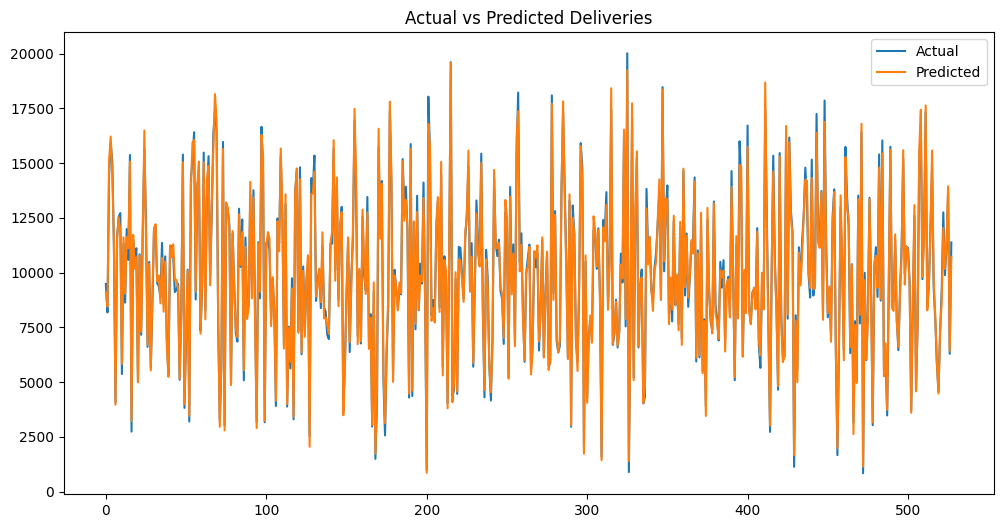

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values,label='Actual')
plt.plot(pred_ridge,label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Deliveries")
plt.show()

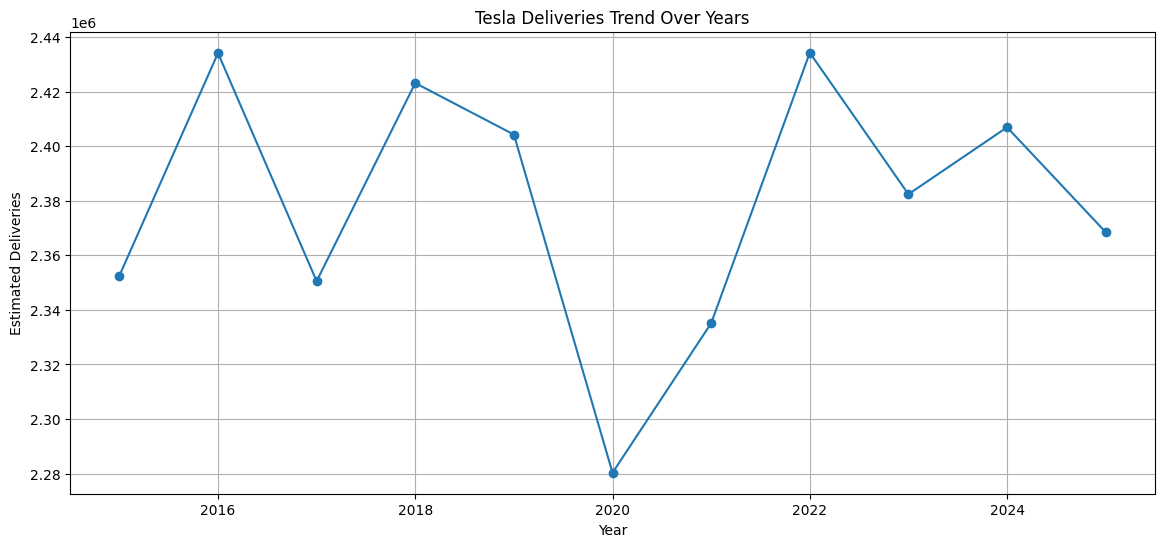

In [ ]:
plt.figure(figsize=(14,6))

monthly_sales = df.groupby(['Year'])['Estimated_Deliveries'].sum()

monthly_sales.plot(marker='o')

plt.title('Tesla Deliveries Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Estimated Deliveries')
plt.grid(True)

plt.show()

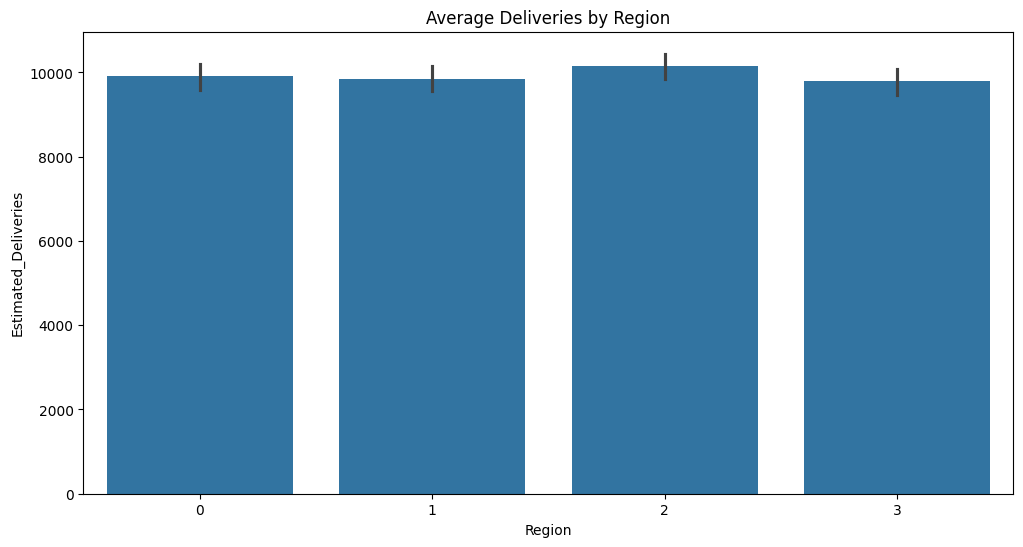

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='Region',
    y='Estimated_Deliveries',
    data=df,
    estimator=np.mean
)

plt.title('Average Deliveries by Region')


plt.show()

# conclusion

An end-to-end machine learning pipeline was developed for Tesla delivery prediction. The workflow included data cleaning, exploratory data analysis, feature engineering, encoding, scaling, lag feature generation, rolling statistics, and stationarity testing. Linear Regression, Ridge Regression, and Lasso Regression were evaluated using MAE, RMSE, and R² metrics. Cross-validation and GridSearchCV were applied to improve model reliability. Ridge Regression achieved the best overall performance and was selected as the final forecasting model.